# Movement Time vs Coherence

Recreates the lab's *Movement Time vs Coherence* figure from the published behavioral data.

**Idea.** For each trial we know two things:
1. **Coherence** — how easy the visual stimulus was (`|DV|` × 100). 100 % = unambiguous, ~10 % = barely distinguishable.
2. **Movement time (MT)** — how long the mouse took to physically run from the center port to the answer port (the duration of the `Movement to Lateral Port` epoch).

We split trials into three coherence bins and three groups (all / correct / error) and plot mean MT ± SEM.

**Data source:** `paper_fast_slow-main/data/2p/df_all_by_epoch_df_f_filtered.pkl`.

## 1. Imports and load

In [4]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_FP = Path('paper_fast_slow-main') / 'data' / '2p' / 'df_all_by_epoch_df_f_filtered.pkl'
with open(DATA_FP, 'rb') as f:
    df = pickle.load(f)

print('Rows:', len(df))
print('Columns:', list(df.columns))
df.head(2)

/var/folders/2s/lfytcs_17wn28f5jlx266jz00000gn/T/ipykernel_47180/3243660211.py:10: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  df = pickle.load(f)


Rows: 22468
Columns: ['Name', 'Date', 'SessionNum', 'TrialNumber', 'MaxTrial', 'MinSample', 'calcStimulusTime', 'ChoiceCorrect', 'ChoiceLeft', 'EarlyWithdrawal', 'PrevChoiceCorrect', 'PrevChoiceLeft', 'DV', 'DVstr', 'PrevDV', 'Difficulty1', 'Difficulty2', 'Difficulty3', 'Difficulty4', 'ShortName', 'epoch', 'epoch_time', 'trace_start_idx', 'trace_end_idx', 'traces_sets', 'sole_owner', 'acq_sampling_rate', 'state_id', 'BrainRegion', 'Layer']


,Name,Date,SessionNum,TrialNumber,MaxTrial,MinSample,calcStimulusTime,ChoiceCorrect,ChoiceLeft,EarlyWithdrawal,...,epoch,epoch_time,trace_start_idx,trace_end_idx,traces_sets,sole_owner,acq_sampling_rate,state_id,BrainRegion,Layer
0,GP4-23,2022-06-26,2,42,333,0.3,1.1627,1.0,1.0,0,...,Wait Trial Start,0.332856,20,29,"{'neuronal': {1: [13.933693, 13.699255, 13.238...",False,30.043,1,15,L23
1,GP4-23,2022-06-26,2,42,333,0.3,1.1627,1.0,1.0,0,...,Sampling,1.164997,30,64,"{'neuronal': {1: [13.933693, 13.699255, 13.238...",False,30.043,8,15,L23


## 2. Extract movement-time-per-trial

The dataframe has one row per (trial, epoch). The duration of the `Movement to Lateral Port` epoch *is* the movement time, in seconds (`epoch_time`).

In [5]:
mv = df[df.epoch == 'Movement to Lateral Port'].copy()
mv = mv[mv.ChoiceCorrect.notnull()]            # drop trials with no choice
mv['MT'] = mv.epoch_time                        # seconds
mv['DVabs'] = mv.DV.abs()                       # 0..1, |DV|

print(f'{len(mv):,} trials')
print(f'  correct: {(mv.ChoiceCorrect == 1).sum():,}')
print(f'  error:   {(mv.ChoiceCorrect == 0).sum():,}')
mv.MT.describe()

5,408 trials
  correct: 4,197
  error:   1,211


count    5408.000000
mean        0.412931
std         0.651247
min         0.166428
25%         0.299571
50%         0.332856
75%         0.399427
max        17.241953
Name: MT, dtype: float64

Notice `max ≈ 17 s`. Those are distracted/aborted trials; we trim them next so they don't blow up the means.

## 3. Coherence binning

Three equal-width bins on `|DV|`: `[0, 1/3, 2/3, 1]`. Bin midpoints land at **17 %, 50 %, 83 %** — matching the x-positions on the lab's figure.

In [6]:
BIN_EDGES = np.array([0.0, 1/3, 2/3, 1.01])
BIN_MIDS_PCT = (BIN_EDGES[:-1] + np.minimum(BIN_EDGES[1:], 1.0)) / 2 * 100
print('Bin midpoints (%):', np.round(BIN_MIDS_PCT, 1))

mv['Bin'] = pd.cut(mv.DVabs, BIN_EDGES, include_lowest=True, labels=False)
mv.Bin.value_counts().sort_index()

Bin midpoints (%): [16.7 50.  83.3]


Bin
0    1335
1    1866
2    2207
Name: count, dtype: int64

## 4. Trim outliers per bin

Per bin, keep only trials with MT between the 1st and 99th percentile. Without this the long-tail trials dominate the means and the y-axis stretches to ~0.7 s — far above the published figure.

In [7]:
def trim_tails(g, lo=1, hi=99):
    qlo, qhi = np.percentile(g.MT, [lo, hi])
    return g[(g.MT >= qlo) & (g.MT <= qhi)]

mv = mv.groupby('Bin', group_keys=False).apply(trim_tails, include_groups=False)
mv['Bin'] = pd.cut(mv.DVabs, BIN_EDGES, include_lowest=True, labels=False)  # rebin (column got dropped)
print(f'{len(mv):,} trials after trim')

5,320 trials after trim


## 5. Compute mean & SEM per bin, per series

In [11]:
def stats(g):
    return pd.Series({'mean': g.MT.mean(), 'sem': g.MT.sem()})

series = {
    'Movement Time All':     mv,
    'Movement Time Correct': mv[mv.ChoiceCorrect == 1],
    'Movement Time False':   mv[mv.ChoiceCorrect == 0],
}

for name, sub in series.items():
    s = sub.groupby('Bin').apply(stats, include_groups=False).sort_index()
    print(f'\n{name}  (n={len(sub):,})')
    print(s.round(3))
    print(len(sub))


Movement Time All  (n=5,320)
      mean    sem
Bin              
0    0.376  0.007
1    0.349  0.003
2    0.367  0.004
5320

Movement Time Correct  (n=4,144)
      mean    sem
Bin              
0    0.369  0.009
1    0.343  0.003
2    0.356  0.004
4144

Movement Time False  (n=1,176)
      mean    sem
Bin              
0    0.384  0.011
1    0.376  0.007
2    0.448  0.021
1176


## 6. Plot

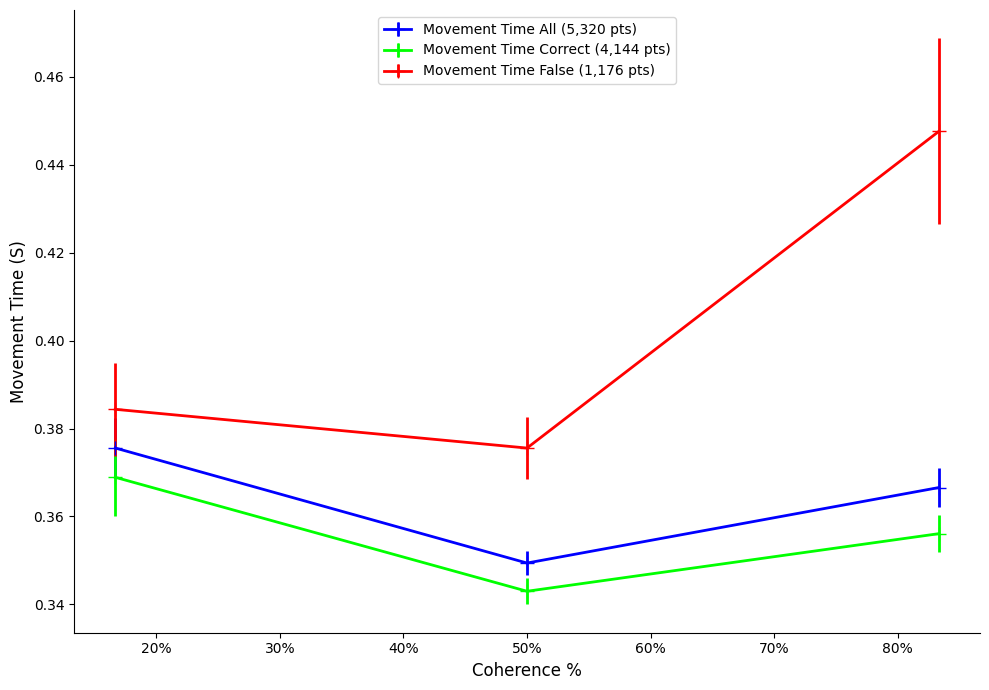

In [9]:
colors = {
    'Movement Time All':     'blue',
    'Movement Time Correct': 'lime',
    'Movement Time False':   'red',
}

fig, ax = plt.subplots(figsize=(10, 7))
for name, sub in series.items():
    s = sub.groupby('Bin').apply(stats, include_groups=False).sort_index()
    ax.errorbar(
        BIN_MIDS_PCT, s['mean'].values, yerr=s['sem'].values,
        fmt='-+', capsize=0, linewidth=2, markersize=10,
        color=colors[name],
        label=f'{name} ({len(sub):,} pts)',
    )

ax.set_xlabel('Coherence %', fontsize=12)
ax.set_ylabel('Movement Time (S)', fontsize=12)
ax.set_xticks(np.arange(20, 90, 10))
ax.set_xticklabels([f'{t}%' for t in np.arange(20, 90, 10)])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper center', frameon=True, fontsize=10)
plt.tight_layout()
plt.savefig('movement_time_vs_coherence.png', dpi=150)
plt.show()

## 7. What the plot says

- **Correct trials (green)** get faster as the stimulus becomes clearer — the mouse commits sooner when it's confident.
- **Error trials (red)** are slower than correct trials at every coherence, and *much* slower on the easiest trials. When a mouse fails an obvious trial, it likely noticed mid-movement that something was off — a 'change of mind' signature.
- **Therefore movement time can serve as a behavioral readout of internal certainty** — the entry point into the neural-correlates question.